# Beta Distribution
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* Shayan Maleki

*SID:* 810102515

The objective of this notebook is to estimate the probability of getting tails in a coin flip using a Bayesian approach.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union
from scipy.integrate import quad
import pandas as pd

<h1>EXPLANATION FOR THE CLASS:</h1>
    i implemented the unnormalized pdf first from the formula we know before.
    then i calculated the 1/c (the normalization constant) by getting its integral. as we know the integral of a pdf function should be 1 so i <b><i>learned</i></b> how to get integral like this and got the unnormalized integral from 0 to 1 , it gave us the 'c' so i returned 1/c as the constant i hope the explanation for the integral is enough.
    at last i used these function to calculate the real pdf in the pdf function.

In [2]:
class BetaDistribution:
    """
    Represents a beta distribution with the given shape parameters.
    """

    def __init__(self, alpha: float, beta: float):
        """
        Args:
            alpha (float): The first shape parameter of the beta distribution.
            beta (float): The second shape parameter of the beta distribution.
        """

        ######################  TODO  ########################
        self.alpha=alpha
        self.beta=beta
        ######################  TODO  ########################

    def pdf(self, x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
        """
        Calculates the normalized probability density function (PDF) of the beta distribution at the given input value(s).
        Args:
            x (float or np.ndarray): The input value(s) to evaluate the beta distribution PDF at.
        Returns:
            pdf (float or np.ndarray): The normalized probability density function evaluated at the input value(s).
        """
        ######################  TODO  ########################
        theConstant=self.__calculate_normalization_constant()
        unNormalfx=self.__unnormalized_pdf(x)
        pdf=theConstant*unNormalfx
        return pdf
        ######################  TODO  ########################

    def __unnormalized_pdf(self, x: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
        """
        Calculates the unnormalized probability density function (PDF) of the beta distribution at the given input value(s).

        Args:
            x (float or np.ndarray): The input value(s) to evaluate the unnormalized beta distribution PDF at.

        Returns:
            pdf (float or np.ndarray): The unnormalized probability density function evaluated at the input value(s).
        """
        ######################  TODO  ########################
        fx=x**(self.alpha-1)*(1-x)**(self.beta-1)
        return (fx)
        ######################  TODO  ########################

    def __calculate_normalization_constant(self):
        """
        Calculates the normalization constant for the beta distribution.
        This constant is used to ensure that the total probability under the PDF is 1.
        """
        ######################  TODO  ########################
        # Proceed with the numerical approach
        def betaunNormalPdf(x):
            fx=x**(self.alpha-1)*(1-x)**(self.beta-1)
            return (fx)
        theConstant=quad(betaunNormalPdf,0,1)[0]
        return 1/theConstant
        ######################  TODO  ########################

    what i am going to do in the section below is that i want to plot the beta distribution with a alpha =4 and beta =10 i generate 1000 xs from 0 to 1 then add the result for each x in y then plot the y.

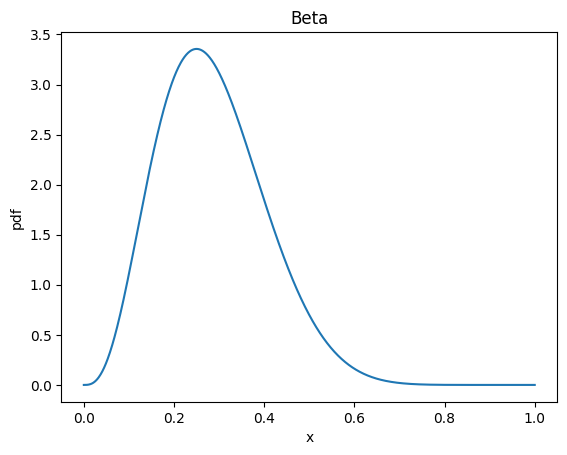

In [3]:
def plot_beta_dist(beta: BetaDistribution):
    """
    Plots the probability density function of the given beta distribution.

    Args:
        beta (BetaDistribution): The beta distribution instance to plot.
    """
    ######################  TODO  ########################
    # Do not forget to add title, labels, and legend.
    x=np.linspace(0,1,1000)
    y=list()
    for i in x:
        y.append(beta.pdf(i))
    plt.plot(x, y)
    plt.title('Beta') 
    plt.xlabel('x') 
    plt.ylabel('pdf') 
    plt.show()
beta = BetaDistribution(4, 10) 
plot_beta_dist(beta)
    ######################  TODO  ########################

Read the `coint_flips.txt` file and plot the posterior distributions after every 50 trials for two prior probabilities:
1. Uniform distribution 
2. $Beta (4, 10)$

    here i opened the file the data then added each line which represent the h or t in the HorTdata

In [4]:
######################  TODO  ########################
# Read coin_flips.txt
data=open('data/coin_flips.txt','r')
HorTdata=list()
for line in data:
    HorTdata.append(line)
######################  TODO  ########################

## Prior: Uniform

**Hint:** use `plt.figure(figsize=(25, 20))` and `plt.subplot(4, 5, ...)`

    here i am going to assume my prior alpha and beta as 1 because when we dont have any infornation about them we should concider them a uniform distribution.
    then i slice the hortdata 50 by 50 and add 50 each time . it means the first time i will simulate the first 50 and update my priors from that then i simulate it for the first 100 with the new alpha and beta i continue to do that untill the whole hortdata is simulated then the post parametheres would be my final a;pha and beta and i calculate the mean and var based on them.

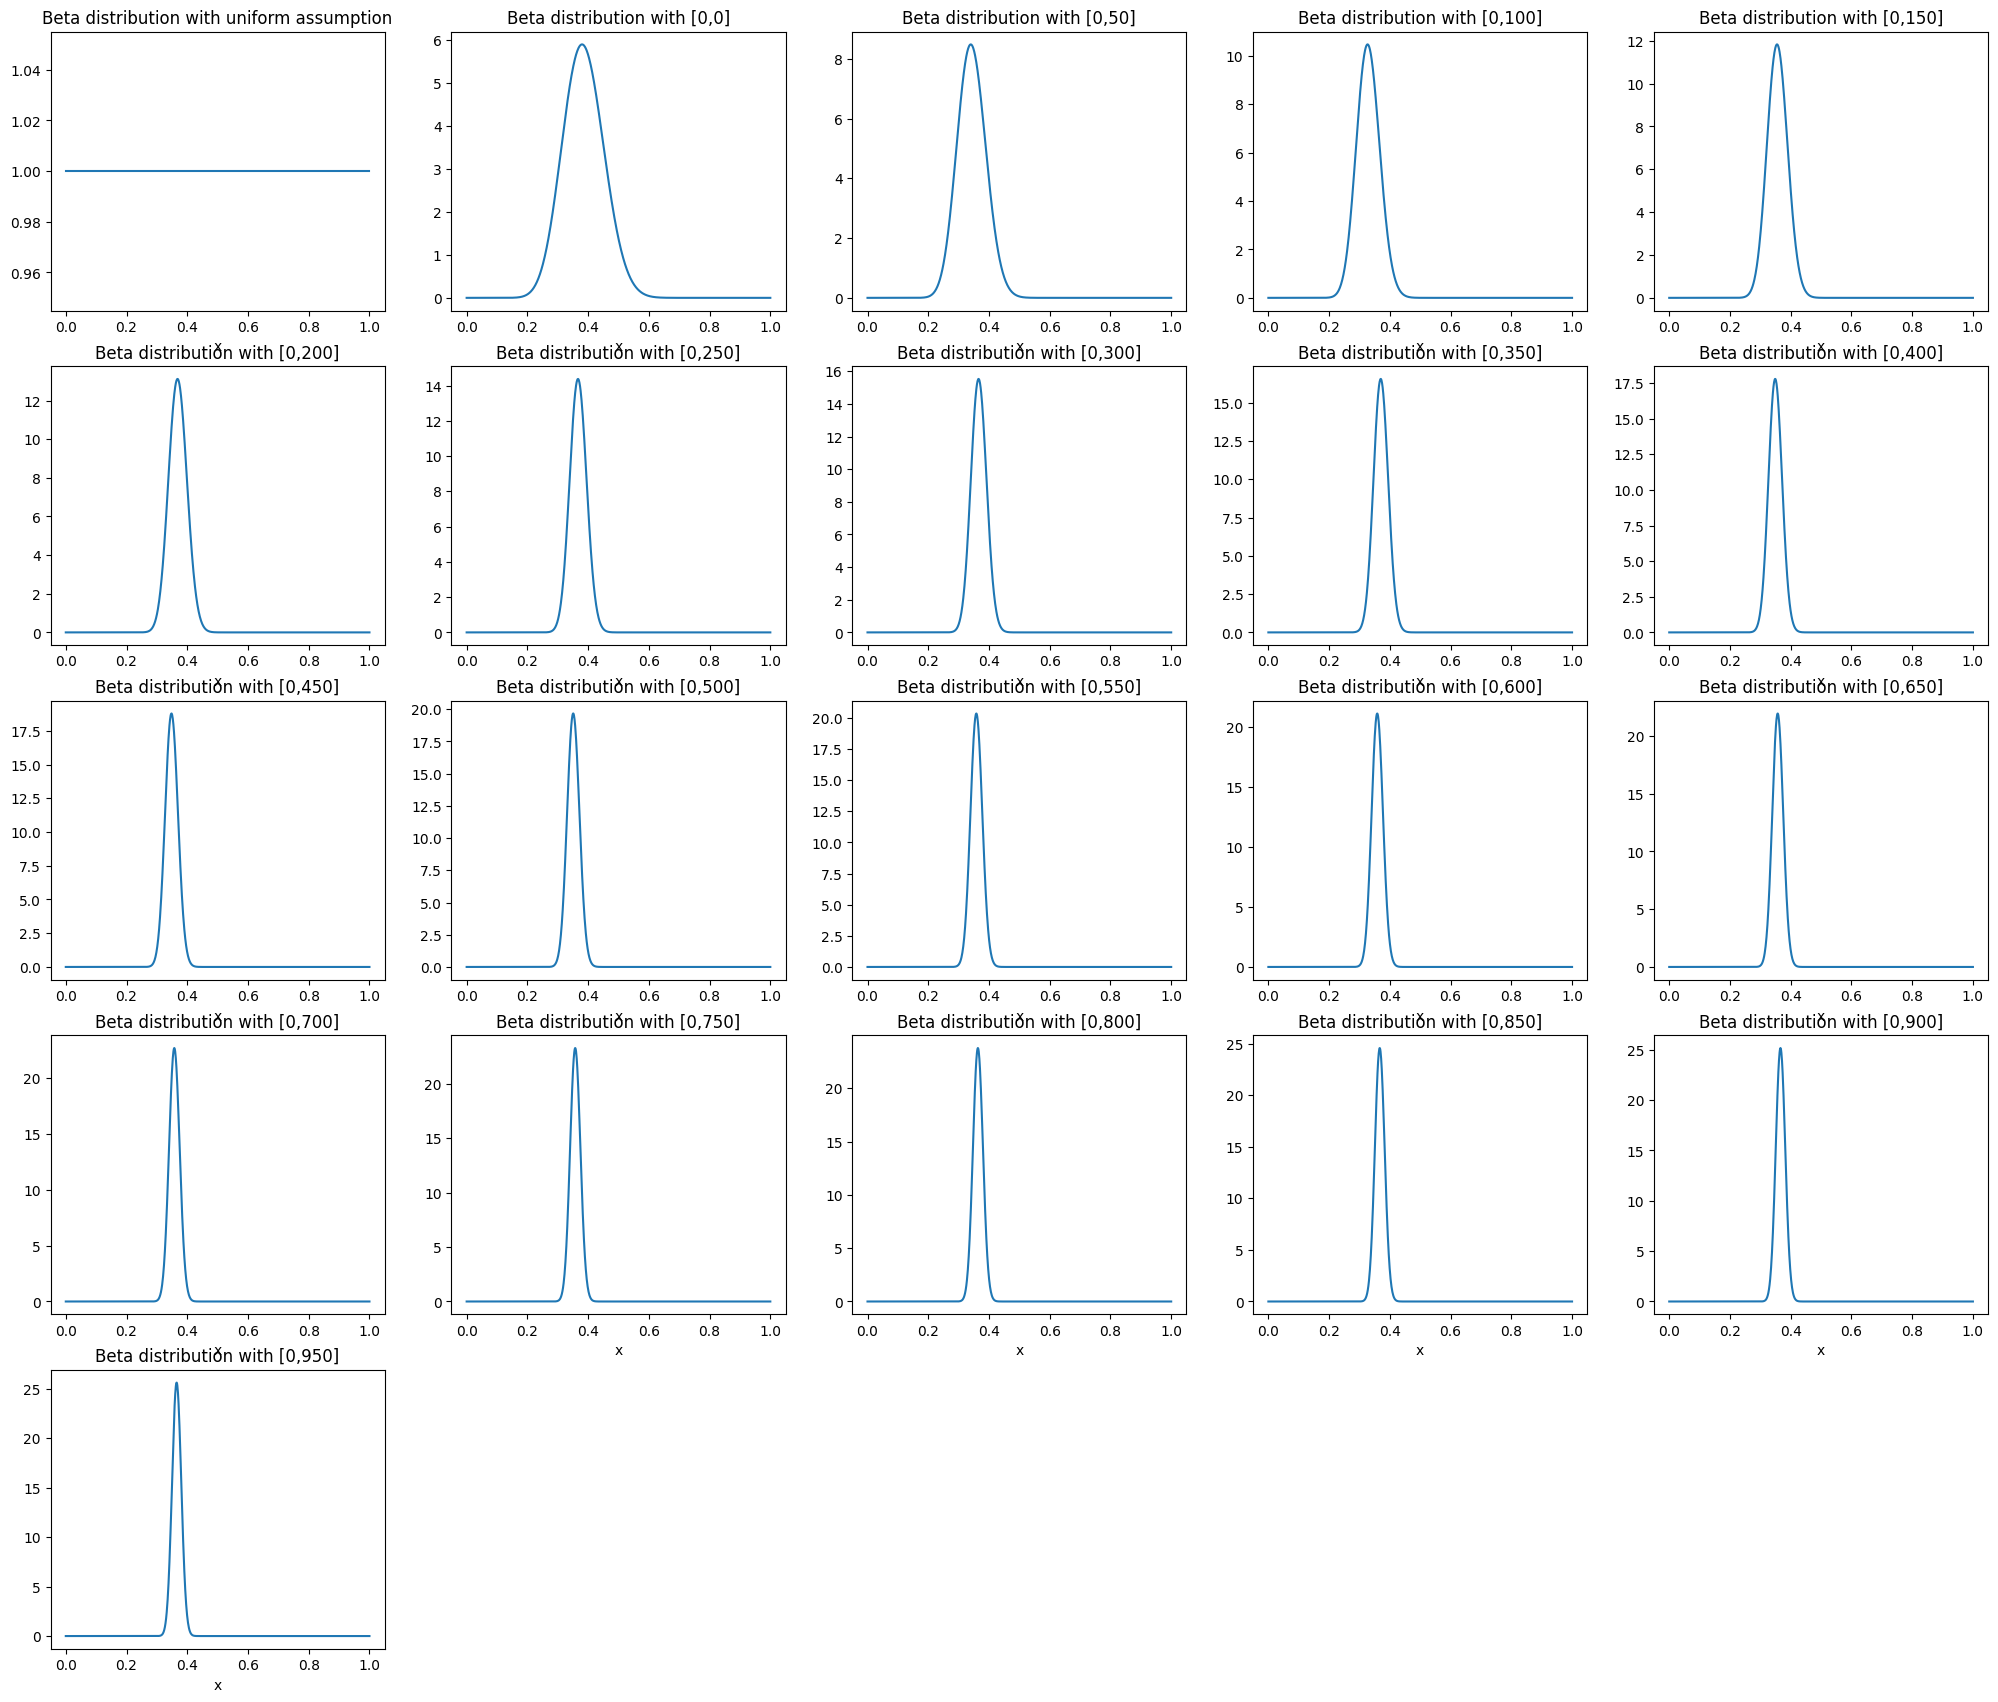

In [13]:
######################  TODO  ########################
def calculateHeadsOrTalesCount(data):
    headsCount=0
    talesCount=0
    for i in data :
        if i.strip()=='H':
            headsCount+=1
        else:
            talesCount+=1
    return ((headsCount,talesCount))
plt.figure(figsize=(25, 21))
priorAlpha=1
priorBeta=1
uniformAssumed=BetaDistribution(priorAlpha,priorBeta)
x = np.linspace(0, 1, 1000)
y = uniformAssumed.pdf(x)
plt.subplot(5, 5, 1)
plt.plot(x, y)
plt.title('Beta distribution with uniform assumption') 
plt.xlabel('x') 
chartCount=2
for i in range(0,len(HorTdata),50):
    subDate=HorTdata[0:i+50]
    headsOrTales=calculateHeadsOrTalesCount(subDate)
    posterierAlpha=priorAlpha+headsOrTales[0]
    posterierBeta=priorBeta+headsOrTales[1]
    newBetaDistribution=BetaDistribution(posterierAlpha,posterierBeta)
    x = np.linspace(0, 1, 1000)
    y = newBetaDistribution.pdf(x)
    plt.subplot(5, 5,chartCount)
    plt.plot(x, y)
    plt.title('Beta distribution with [0,'+str(i)+']') 
    plt.xlabel('x') 
    chartCount+=1
######################  TODO  ########################

Now calculate the final posterior mean and variance.

In [17]:
######################  TODO  ########################
mean=posterierAlpha/(posterierAlpha+posterierBeta)
var=(posterierAlpha*posterierBeta)/(((posterierAlpha+posterierBeta)**2)*(posterierAlpha+posterierBeta+1))
print ('mean is',mean)
print ('var is',var)
######################  TODO  ########################

mean is 0.3652694610778443
var is 0.00023115421922407326


## Prior: $Beta(4, 10)$

the differance here is that we have some information about our initial paramethers and we dont have to assume them a uniform distribution.

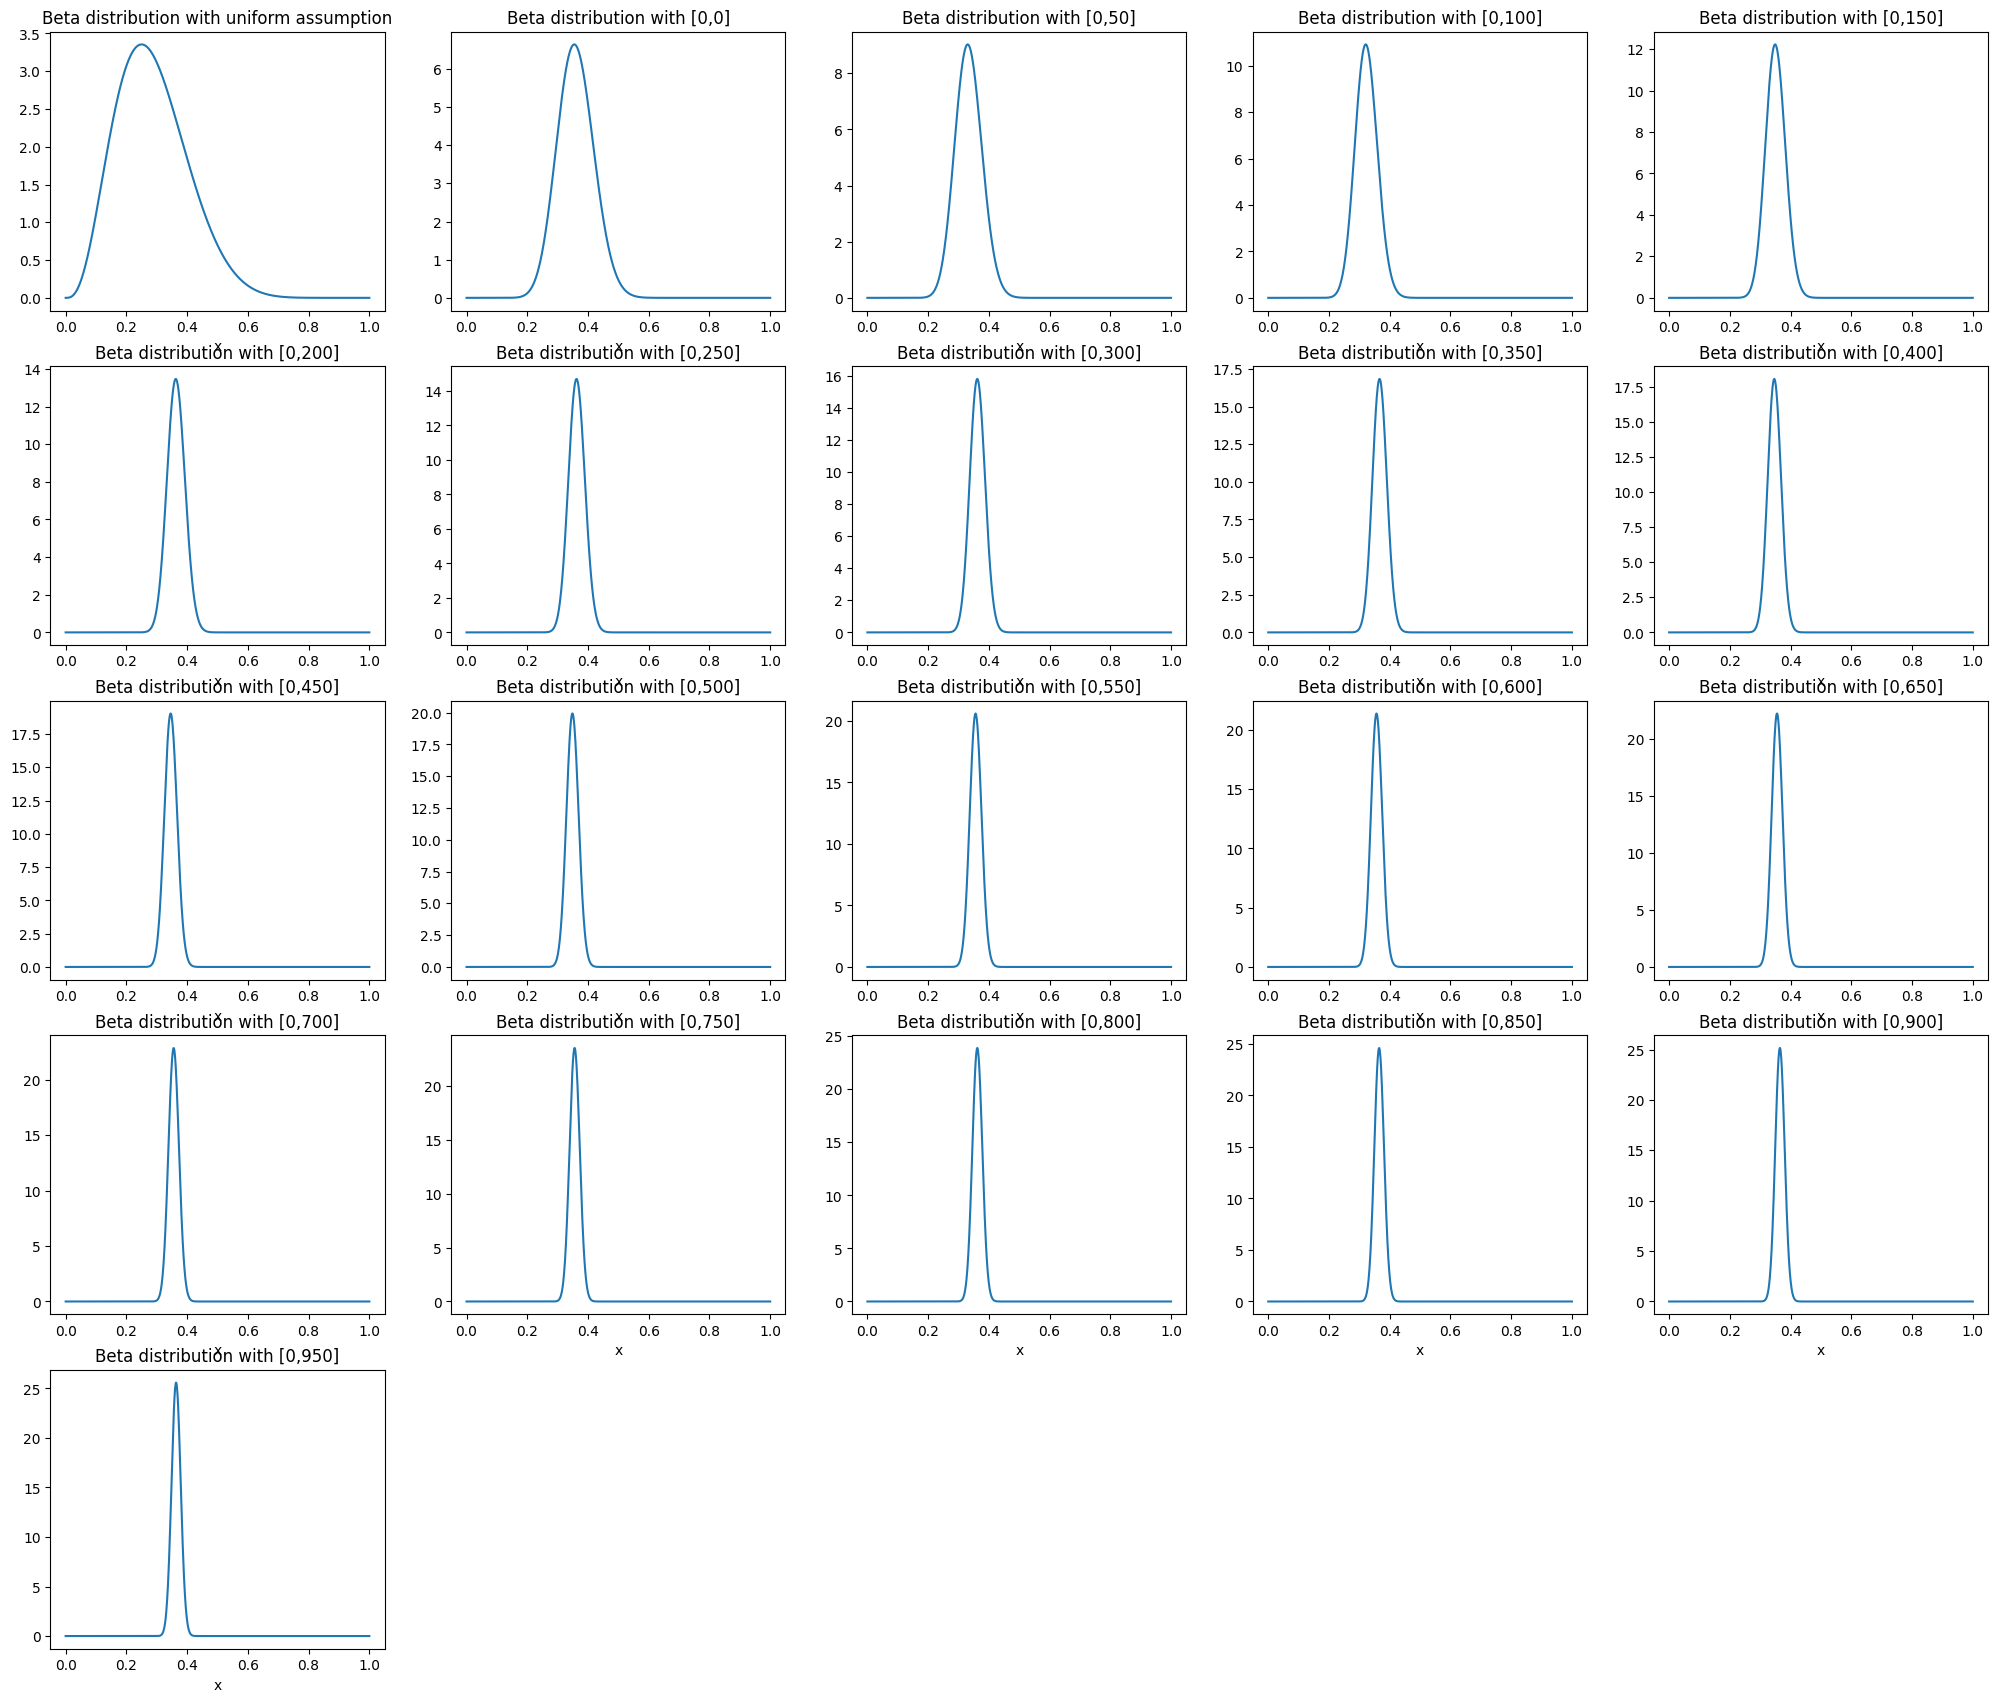

In [18]:
######################  TODO  ########################
######################  TODO  ########################
def calculateHeadsOrTalesCount(data):
    headsCount=0
    talesCount=0
    for i in data :
        if i.strip()=='H':
            headsCount+=1
        else:
            talesCount+=1
    return ((headsCount,talesCount))
plt.figure(figsize=(25, 21))
priorAlpha=4
priorBeta=10
uniformAssumed=BetaDistribution(priorAlpha,priorBeta)
x = np.linspace(0, 1, 1000)
y = uniformAssumed.pdf(x)
plt.subplot(5, 5, 1)
plt.plot(x, y)
plt.title('Beta distribution with uniform assumption') 
plt.xlabel('x') 
chartCount=2
for i in range(0,len(HorTdata),50):
    subDate=HorTdata[0:i+50]
    headsOrTales=calculateHeadsOrTalesCount(subDate)
    posterierAlpha=priorAlpha+headsOrTales[0]
    posterierBeta=priorBeta+headsOrTales[1]
    newBetaDistribution=BetaDistribution(posterierAlpha,posterierBeta)
    x = np.linspace(0, 1, 1000)
    y = newBetaDistribution.pdf(x)
    plt.subplot(5, 5,chartCount)
    plt.plot(x, y)
    plt.title('Beta distribution with [0,'+str(i)+']') 
    plt.xlabel('x') 
    chartCount+=1
######################  TODO  ########################
######################  TODO  ########################

Now calculate the final posterior mean and variance.

In [19]:
######################  TODO  ########################
mean=posterierAlpha/(posterierAlpha+posterierBeta)
var=(posterierAlpha*posterierBeta)/(((posterierAlpha+posterierBeta)**2)*(posterierAlpha+posterierBeta+1))
print ('mean is',mean)
print ('var is',var)
######################  TODO  ########################

mean is 0.363905325443787
var is 0.0002280573788743236


the interesting result here is that the mean and var in both ways(assuming uniform and beta(4,10)) had the almost same result it means that it doesnt matter what our initial distributions were the more we update the paramethers the more we get close to the actual and correct paramethers.